In [1]:
import sys
sys.path.append("/home/landelle/pytorch-cifar/models")
#import util
import resnet
import numpy as np
import torch
import torchvision

import mix_utils

In [2]:

transform = torchvision.transforms.transforms.Compose([
    torchvision.transforms.transforms.ToTensor()
])

base_trainset = torchvision.datasets.CIFAR10(root='/data/landelle/datasets', train=True, download=True, transform=transform)
base_testset = torchvision.datasets.CIFAR10(root='/data/landelle/datasets', train=False, download=True, transform=transform)

base_trainset, base_testset

Files already downloaded and verified
Files already downloaded and verified


(Dataset CIFAR10
     Number of datapoints: 50000
     Root location: /data/landelle/datasets
     Split: Train
     StandardTransform
 Transform: Compose(
                ToTensor()
            ), Dataset CIFAR10
     Number of datapoints: 10000
     Root location: /data/landelle/datasets
     Split: Test
     StandardTransform
 Transform: Compose(
                ToTensor()
            ))

In [5]:

BATCH_SIZE = 100
N_BATCHES_IN_TRAIN_SET = len(base_trainset) // BATCH_SIZE
N_BATCHES_IN_TEST_SET = len(base_testset) // BATCH_SIZE

NUM_WORKERS = 8

# Fixed learning rate
LR = 0.05 #0.005 LR=0.1 is used by kuangliu with his implementation of ResNet18 for epochs [0;150)

# CIFAR10 number of classes
NUM_CLASS = 10

# CIFAR10 image metadata
CHANNEL, IMAGE_SIZE, _ = base_trainset[0][0].shape
print("images are:", IMAGE_SIZE, CHANNEL)


images are: 32 3


In [14]:
def pmix_masks(n, im_dim, single):
    """ Makes pmix masks
    Args:
        n: int, the number of masks to make (one for each unique label)
        im_dim: tuple, width and height of images and thus masks
        single: bool, when activated this function will return the same mask for each label
    Return:
        np.array of shape [n, im_dim[0], im_dim[1]], the list of masks for respective labels
    """
    masks = np.zeros((n, *im_dim), dtype=int)
    for i in range(masks.shape[0]):
        if single and i > 0:
            masks[i] = masks[0]
            continue
        rrange = np.arange(0, im_dim[0]*im_dim[1])
        np.random.shuffle(rrange)
        masks[i] = rrange.reshape(im_dim)
    return masks

def pmix_images(imgs, labels, masks):
    H, W = masks[0].shape
    
    # Makes empty result array
    pmixed = np.zeros(imgs.shape)
    for i in range(imgs.shape[0]):
        # Flatten mask for this label
        rs_mask = masks[labels[i]].reshape(W * H)
        # Flatten image
        rs_img = imgs[i].reshape((-1, W * H))
        # Mix pixels of img according to mask, accross each channel
        rs_result = rs_img[:, rs_mask]
    
        pmixed[i] = rs_result.reshape((-1, W, H))
    return pmixed

In [18]:
class PmixupCifar10(torch.utils.data.Dataset):

    def __init__(self, base_set, lambda_vec, seed, *, single_mask=True, preset_masks=None, sample_size=None, transform=None):
        print("b")
        self.transform = transform   
        
        lam_ = lambda_vec     
        
        L = sample_size if sample_size else base_set.data.shape[0]
        N = lam_.shape[0]
        imgs = np.array(base_set.data[:L])
        
        imgs = np.array(base_set.data[:L])
        
        print("convert imgs into a good shape and type")
        imgs = np.float32(imgs/255.)
        imgs = imgs.transpose((0, 3, 1, 2))
        
        labels = np.array(base_set.targets[:L])
        unique = np.unique(labels)
        n_unique = unique.shape[0]
        print("Labels:", unique, "=> n_unique:", n_unique)
        
        print("e")
        indices = mix_utils.buckets_intraclass(labels, N, L)
        ingredients = imgs[indices]
        
        print("f")
        lam_mask = np.concatenate([
            lam_[i] * np.ones((1, *imgs.shape))
            for i in range(lam_.shape[0])], axis=0)

        print("g")
        mixed = (lam_mask * ingredients).sum(axis=0)
        

        print("g")
        #self.pmix_masks = pmix_masks(n_unique, mixed.shape[2:4], single_mask) if preset_masks is None else preset_masks
        #self.pmixed = pmix_images(mixed, labels, self.pmix_masks)
        self.pmixed = mixed
        self.labels = labels
        #show_np_array(mixed[0])
        

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
        img = self.pmixed[idx]
        target = self.labels[idx]
        
        if self.transform is not None:
            img = self.transform(img).transpose(1, 0).transpose(1, 2)
            if not img.shape == (3, 32, 32):
                raise Exception()
        return img, target

In [138]:
class PmixCifar10(torch.utils.data.Dataset):

    def __init__(self, base_set, pmix_seed, *, single_mask=True, preset_masks=None, sample_size=None, transform=None):
        print("b")
        self.transform = transform        
        
        L = sample_size if sample_size else base_set.data.shape[0]
        imgs = np.array(base_set.data[:L])
        
        print("c")
        imgs = np.float32(imgs/255.)
        imgs = imgs.transpose((0, 3, 1, 2))
        #TODO remove
        self.source_imgs = imgs
        
        print("d")
        labels = np.array(base_set.targets[:L])
        unique = np.unique(labels)
        n_unique = unique.shape[0]
        print("Labels:", unique, "=> n_unique:", n_unique)

        print("g")
        self.pmix_masks = pmix_masks(n_unique, imgs.shape[2:4], single_mask) if preset_masks is None else preset_masks
        self.pmixed = pmix_images(imgs, labels, self.pmix_masks)
        self.labels = labels
        #show_np_array(mixed[0])
        

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
        img = self.pmixed[idx]
        src_img = self.source_imgs[idx]
        target = self.labels[idx]
        
        if self.transform is not None:
            img = self.transform(img).transpose(1, 0).transpose(1, 2)
            if not img.shape == (3, 32, 32):
                raise Exception()
        return img, src_img, target

In [338]:

trainset = PmixCifar10(base_trainset,
                                2019,
                                sample_size=100,
                                transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)

device = torch.device('cuda')
    
for imgs, src_imgs, targets in trainloader:
    #print(targets.shape)
    #print("class:", base_trainset.classes[targets[0]])
    #mix_utils.show_np_array(imgs[0])
    LAMBDA_VEC = np.array((.5, .5))
    NMIX = LAMBDA_VEC.shape[0]
    lam_rs = LAMBDA_VEC.reshape((-1, 1, 1, 1, 1))
    lam_rs_tensor = torch.from_numpy(lam_rs).float().to(device)
    labels, images = targets.to(device), imgs.to(device).float()
    images, ys, perms = mixup_data_nmix(NMIX, images, labels, lam_rs_tensor)
    #print(images[0].shape)
    src_a = src_imgs[perms[0][0]]
    src_b = src_imgs[perms[1][0]]
    ing_a = imgs[perms[0][0]]
    ing_b = imgs[perms[1][0]]
    lab_a = base_trainset.classes[targets[perms[0][0]]]
    lab_b = base_trainset.classes[targets[perms[1][0]]]
    res = images[0]
    break
    

    

b
c
d
Labels: [0 1 2 3 4 5 6 7 8 9] => n_unique: 10
g


'truck'

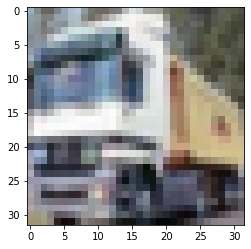

In [339]:
mix_utils.show_np_array(src_a)
lab_a

'frog'

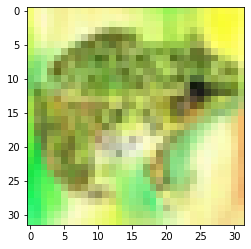

In [340]:
mix_utils.show_np_array(src_b)
lab_b

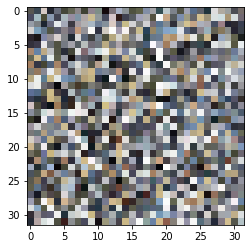

In [341]:
mix_utils.show_np_array(ing_a)

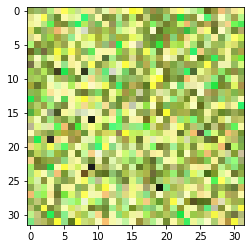

In [342]:
mix_utils.show_np_array(ing_b)

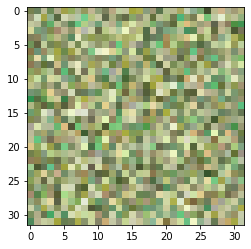

In [343]:
mix_utils.show_np_array(res.cpu())

In [66]:

from nmixup import resnet18, get_print, mixup_data_nmix

USE_CUDA = True
N_EPOCHS = 100
N_BATCHES = None
LAMBDA_VEC = np.array((.75, .25))
NMIX = LAMBDA_VEC.shape[0]

model_getter = resnet18

lam_rs = LAMBDA_VEC.reshape((-1, 1, 1, 1, 1))
lam_rs_tensor = torch.from_numpy(lam_rs).float().to(device)
        
for i in range(5):
    print_ = get_print(True, fname="results_pmixup2_"+str(i))
    
    device = torch.device('cuda' if USE_CUDA else 'cpu')
    model = model_getter().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = torch.nn.CrossEntropyLoss()

    # switch to train mode
    model.train()
    for epoch in range(1, N_EPOCHS + 1):
        print_("Epoch[{}/{}]".format(epoch, N_EPOCHS))
        for batch_id, (images, labels) in enumerate(trainloader):
            if N_BATCHES and batch_id > N_BATCHES:
                break
            labels, images = labels.to(device), images.to(device).float()
            images, ys, perms = mixup_data_nmix(NMIX, images, labels, lam_rs_tensor)
            #outputs = model(images.float())
            outputs = model(images)
            loss = mixup_criterion_nmix(criterion, outputs, ys, lam_rs_tensor)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if batch_id % 50 == 0:
                print_('Loss :{:.4f} Epoch[{}/{}] Batch[{}/{}] batch_shape:{}'.format(
                    loss.item(), epoch, N_EPOCHS, batch_id, N_BATCHES_IN_TRAIN_SET, images.shape))

    test_accs = {}

    # switch to evaluate mode
    model.eval()
    with torch.no_grad():
        correct = 0
        total = 0
        for images, labels in testloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images.float())
            predicted = torch.argmax(outputs, dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        # Output test accuracy
        test_acc = 100 * correct / total
        print_('Test Accuracy of the model on the test images: {} %'.format(test_acc))

        test_acc = test_acc



Epoch[1/100]
Loss :2.5232 Epoch[1/100] Batch[0/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :2.2999 Epoch[1/100] Batch[50/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :2.3002 Epoch[1/100] Batch[100/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :2.3061 Epoch[1/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :2.3031 Epoch[1/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :2.3122 Epoch[1/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :2.3128 Epoch[1/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :2.3074 Epoch[1/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :2.2753 Epoch[1/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :2.2164 Epoch[1/100] Batch[450/500] batch_shape:torch.Size([100, 3, 32, 32])
Epoch[2/100]
Loss :2.2024 Epoch[2/100] Batch[0/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :2.1845 Epoch[2/100] Batch[50/500] batch_shape:torch.Size([100, 3, 32, 3

Loss :1.7017 Epoch[10/100] Batch[450/500] batch_shape:torch.Size([100, 3, 32, 32])
Epoch[11/100]
Loss :1.8181 Epoch[11/100] Batch[0/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.7882 Epoch[11/100] Batch[50/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.6879 Epoch[11/100] Batch[100/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.7542 Epoch[11/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.8198 Epoch[11/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.6991 Epoch[11/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.5568 Epoch[11/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.5980 Epoch[11/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.6618 Epoch[11/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.7192 Epoch[11/100] Batch[450/500] batch_shape:torch.Size([100, 3, 32, 32])
Epoch[12/100]
Loss :1.6534 Epoch[12/100] Batch[0/500] batch_shape:torch.Size

Loss :1.3778 Epoch[20/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.4270 Epoch[20/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.4837 Epoch[20/100] Batch[450/500] batch_shape:torch.Size([100, 3, 32, 32])
Epoch[21/100]
Loss :1.4571 Epoch[21/100] Batch[0/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.4025 Epoch[21/100] Batch[50/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.4026 Epoch[21/100] Batch[100/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.4730 Epoch[21/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.4036 Epoch[21/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.5679 Epoch[21/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.4608 Epoch[21/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.2846 Epoch[21/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.4550 Epoch[21/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32

Loss :1.3077 Epoch[30/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.4037 Epoch[30/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.3199 Epoch[30/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.2130 Epoch[30/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.3314 Epoch[30/100] Batch[450/500] batch_shape:torch.Size([100, 3, 32, 32])
Epoch[31/100]
Loss :1.3147 Epoch[31/100] Batch[0/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.2368 Epoch[31/100] Batch[50/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.2815 Epoch[31/100] Batch[100/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.2128 Epoch[31/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.4294 Epoch[31/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.1429 Epoch[31/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.2461 Epoch[31/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32

Loss :1.1482 Epoch[40/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.1892 Epoch[40/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.1712 Epoch[40/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.2578 Epoch[40/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.1689 Epoch[40/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.2077 Epoch[40/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.2278 Epoch[40/100] Batch[450/500] batch_shape:torch.Size([100, 3, 32, 32])
Epoch[41/100]
Loss :1.2036 Epoch[41/100] Batch[0/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.1345 Epoch[41/100] Batch[50/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.2132 Epoch[41/100] Batch[100/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0759 Epoch[41/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.2907 Epoch[41/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32

...

Loss :1.1598 Epoch[61/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.1888 Epoch[61/100] Batch[450/500] batch_shape:torch.Size([100, 3, 32, 32])
Epoch[62/100]
Loss :1.1268 Epoch[62/100] Batch[0/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.1450 Epoch[62/100] Batch[50/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0712 Epoch[62/100] Batch[100/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.1306 Epoch[62/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.1861 Epoch[62/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.1277 Epoch[62/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.2543 Epoch[62/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.1797 Epoch[62/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.1305 Epoch[62/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0714 Epoch[62/100] Batch[450/500] batch_shape:torch.Size([100, 3, 32

Loss :1.0738 Epoch[71/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.1028 Epoch[71/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0583 Epoch[71/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.1770 Epoch[71/100] Batch[450/500] batch_shape:torch.Size([100, 3, 32, 32])
Epoch[72/100]
Loss :1.1222 Epoch[72/100] Batch[0/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0994 Epoch[72/100] Batch[50/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.1011 Epoch[72/100] Batch[100/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0905 Epoch[72/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.1124 Epoch[72/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.1035 Epoch[72/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.1225 Epoch[72/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0734 Epoch[72/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32

Loss :1.1206 Epoch[81/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.2030 Epoch[81/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.1016 Epoch[81/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0841 Epoch[81/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0829 Epoch[81/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.1627 Epoch[81/100] Batch[450/500] batch_shape:torch.Size([100, 3, 32, 32])
Epoch[82/100]
Loss :1.1735 Epoch[82/100] Batch[0/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.1500 Epoch[82/100] Batch[50/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0497 Epoch[82/100] Batch[100/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.1064 Epoch[82/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0894 Epoch[82/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.1041 Epoch[82/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32

Loss :1.1529 Epoch[91/100] Batch[100/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0958 Epoch[91/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.1559 Epoch[91/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0804 Epoch[91/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.1160 Epoch[91/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.1156 Epoch[91/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0835 Epoch[91/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.1240 Epoch[91/100] Batch[450/500] batch_shape:torch.Size([100, 3, 32, 32])
Epoch[92/100]
Loss :1.0469 Epoch[92/100] Batch[0/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.1069 Epoch[92/100] Batch[50/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.0940 Epoch[92/100] Batch[100/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.1782 Epoch[92/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32

Test Accuracy of the model on the test images: 19.46 %


In [61]:


testset = PmixCifar10(base_testset,
                                2019,
                                sample_size=50000,
                                transform=transform)


testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)


b
c
d
Labels: [0 1 2 3 4 5 6 7 8 9] => n_unique: 10
g


Test Accuracy of the model on the test images: 18.76 %


In [ ]:

del device, model, optimizer, criterion